## Validation of PVade against DuraMAT experimental campaign ##

In [167]:
import pandas as pd
import numpy as np
import yaml
import pickle
import importlib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# spectra
from scipy.signal import welch
from numpy import hanning
import math

# from postprocessing_functions import *
# importlib.reload(postprocessing_functions) # to reload functions without restarting the notebook

In [168]:
pwd

'/kfs2/projects/pvopt/aps_dfd_2024/PVade/postprocessing'

In [169]:
# copying from https://github.com/brookeslawski/scripts/blob/main/pvade-pproc-aps2024.ipynb
parentdir = '/scratch/bstanisl/pvade/turb_inflow/'
# casepath = 'y20m_turbinflow_duramat_validation/'

# casepath = 'halfwing_turbinflow_duramat_validation_40deg/'
# exp_data_fn = 'DuraMAT_tilt40deg_turbulent_inflow_10min_timeseries.csv'

# casepath = 'halfwing_turbinflow_duramat_validation_neg40deg/'
# exp_data_fn = 'DuraMAT_tiltneg40deg_turbulent_inflow_10min_timeseries.csv'

casepath = 'halfwing_turbinflow_duramat_validation_-10.0deg/'
exp_data_fn = 'DuraMAT_tiltneg10deg_turbulent_inflow_10min_timeseries.csv'

tilts = [-10.0]
# panel_span = 10.0
# panel_chord = 4.1

### Step 1: read in csv data (lift and drag, acceleration at NE corner of panel) ###

In [170]:
# read in lift and drag
output_dir=parentdir+'output/'+casepath
tmp = pd.read_csv(output_dir+'solution/lift_and_drag.csv')
tmp.rename(columns={'#Time': 'Time'}, inplace=True)
tmp = tmp.set_index('Time')
loadsdata = tmp

# read in accelerations
# tmp2 = pd.read_csv(output_dir+'solution/accel_pos.csv')
# loadsdata['accel-x'] = tmp2['#x-pos'].values
# loadsdata['accel-y'] = tmp2['y-pos'].values
# loadsdata['accel-z'] = tmp2['z-pos'].values
# loadsdata['accel-magnitude'] = loadsdata['accel-x']**2 + loadsdata['accel-y']**2 + loadsdata['accel-z']**2

# clean up
del tmp
# del tmp2

loadsdata

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0
Time,,,,,,
0.006,2964.160805,207.718831,-28124.407940,1.313189,0.092024,-12.459737
0.012,1056.314469,81.106633,-2669.463141,0.467971,0.035932,-1.182631
0.018,90.212667,12.537837,1989.193132,0.039966,0.005555,0.881257
0.024,598.048290,15.207128,-799.517326,0.264949,0.006737,-0.354204
0.030,631.153675,12.249932,-1632.194899,0.279615,0.005427,-0.723099
...,...,...,...,...,...,...
29.772,188.111457,8.313842,-701.272649,0.083338,0.003683,-0.310679
29.778,188.128852,8.411267,-704.496935,0.083345,0.003726,-0.312108
29.784,185.317724,8.340084,-705.763568,0.082100,0.003695,-0.312669


### Step 2: Read in post-processed velocity data from PVade sim ###

In [171]:
# read input parameters
with open(output_dir+'input_params.yaml', 'r') as file:
    params = yaml.safe_load(file)

print('tracker_angle = {} m/s'.format(params['pv_array']['tracker_angle']))
dt_sim = params['solver']['dt']
dt_xdmf = params['solver']['save_xdmf_interval']
panel_span = params['pv_array']['panel_span']
panel_chord = params['pv_array']['panel_chord']
tf = params['solver']['t_final']

tracker_angle = -10.0 m/s


In [172]:
# read velocity data
readdata = {}
coords = {}
    
for j, tilt in enumerate(tilts):
    readdata[tilt] = {}
    coords[tilt] = {}

    pkl_fname = f'duramatval_tracker_angle_{tilt}.pkl'
    pkl_path = parentdir+'interp_data/timeseries_data/'+pkl_fname

    print('reading from', pkl_path)

    try:
        with open(pkl_path, 'rb') as f:
            # try:
            readrawdata = pickle.load(f)
                
            # print(rawdata[winddir][tilt][case].keys())
            readdata[tilt]['u'] = readrawdata['u']
            readdata[tilt]['v'] = readrawdata['v']
            readdata[tilt]['w'] = readrawdata['w']
            print('vel data nt, nx, ny, nz = ', np.shape(readdata[tilt]['u']))
    except Exception as e:
        print(f"Error loading pickle file: {e}")

# i think coords are only different for each tilt angle
if 'X' in readrawdata.keys():
    tmpX = readrawdata['X']
    print('coord nx, ny, nz = ', np.shape(tmpX))
    del tmpX

    coords[tilt]['X'] = readrawdata['X']
    coords[tilt]['Y'] = readrawdata['Y']
    coords[tilt]['Z'] = readrawdata['Z']
                        
del readrawdata

ndim = len(np.shape(readdata[tilt]['u']))

reading from /scratch/bstanisl/pvade/turb_inflow/interp_data/timeseries_data/duramatval_tracker_angle_-10.0.pkl
vel data nt, nx, ny, nz =  (2484, 132, 66, 50)
coord nx, ny, nz =  (132, 66, 50)


In [173]:
# create dataframe from velocity data
nt = np.shape(readdata[tilt]['u'])[0]
time_xdmf = np.arange(dt_xdmf, tf+dt_xdmf, dt_xdmf)[0:nt] #np.linspace(dt_xdmf, tf, nt)

xi = coords[tilt]['X'][:,0,0]
yi = coords[tilt]['Y'][0,:,0]
zi = coords[tilt]['Z'][0,0,:]

# velocity signal at sonic location
# [xloc, yloc, zloc] = [-12.36, 0.0, 2.23]
[xloc, yloc, zloc] = [-12.36, 4.5, 2.23]
i = int(np.argmin(np.abs(xi - xloc)))
j = int(np.argmin(np.abs(yi - yloc)))
k = int(np.argmin(np.abs(zi - zloc)))
# print(f'sonic loc indices = {i, j, k}')

vel_data = pd.DataFrame(index=time_xdmf)
# for comp in ['u', 'v', 'w']:
#     vel_data[comp+' (m/s) at inlet'] = readdata[tilt][comp][:,0,j,k]
# for comp in ['u', 'v', 'w']:
#     vel_data[comp+' (m/s) at sonic'] = readdata[tilt][comp][:,i,j,k]
for comp in ['u', 'v', 'w']:
    vel_data[comp+' (m/s)'] = readdata[tilt][comp][:,0,j,k]
vel_data

,u (m/s),v (m/s),w (m/s)
0.012,NaN,NaN,NaN
0.024,NaN,NaN,NaN
0.036,NaN,NaN,NaN
0.048,NaN,NaN,NaN
0.060,NaN,NaN,NaN
...,...,...,...
29.760,5.271834,1.259819,2.262725
29.772,6.112759,1.495122,2.381683
29.784,5.449206,2.213895,1.890591
29.796,4.840822,2.819982,1.748472


In [174]:
# merge sim data
sim_data = pd.merge(loadsdata, vel_data, left_index=True, right_index=True, how='inner')
sim_data

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,u (m/s),v (m/s),w (m/s)
0.012,1056.314469,81.106633,-2669.463141,0.467971,0.035932,-1.182631,NaN,NaN,NaN
0.024,598.048290,15.207128,-799.517326,0.264949,0.006737,-0.354204,NaN,NaN,NaN
0.048,794.689624,9.549827,-2932.681535,0.352065,0.004231,-1.299243,NaN,NaN,NaN
0.060,312.271643,10.252205,-339.675260,0.138343,0.004542,-0.150484,NaN,NaN,NaN
0.072,375.886025,11.679116,-899.398173,0.166526,0.005174,-0.398453,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
29.724,198.163662,6.483155,-716.990558,0.087791,0.002872,-0.317643,4.667479,1.167419,3.356230
29.736,206.104760,6.673659,-744.977677,0.091309,0.002957,-0.330042,4.340408,1.389402,3.008567
29.748,190.206254,7.558280,-696.377923,0.084266,0.003348,-0.308511,4.633940,1.149343,2.555073
29.760,191.957127,7.806190,-713.956411,0.085041,0.003458,-0.316299,5.271834,1.259819,2.262725


In [175]:
# calculate lift and drag coeff
sfc_area = panel_span * panel_chord
sim_data['vel_mag (m/s)'] = (sim_data['u (m/s)']**2 + sim_data['v (m/s)']**2 + sim_data['w (m/s)']**2)**0.5
sim_data['fx_nd_calc'] = (sim_data['fx_0'])/(0.5*1*sim_data['vel_mag (m/s)']**2*sfc_area)
sim_data['fz_nd_calc'] = (sim_data['fz_0'])/(0.5*1*sim_data['vel_mag (m/s)']**2*sfc_area)

### Step 3: read in measurement data from DuraMAT ###

In [176]:
# read in experimental data
def read_csv_data(raw_data):
    # read csv
    exp_data = raw_data
    
    # construct time index
    tmp = (exp_data.index[1]-exp_data.index[0])
    dt_sonic1 = round(tmp.total_seconds(), 3)
    tf_sonic1 = len(exp_data) * dt_sonic1 # final time [s]
    t_sonic1 = np.arange(0.0, tf_sonic1, dt_sonic1)

    exp_data['u (m/s)'] = -1.0*exp_data['u (m/s)'] # to make it positive from the west
    exp_data['Time'] = t_sonic1
    exp_data = exp_data.set_index('Time')

    return tf_sonic1, exp_data
    
raw_exp_data = pd.read_csv(exp_data_fn, index_col='Time')
raw_exp_data.index = pd.to_datetime(raw_exp_data.index)

tf_sonic1, exp_data = read_csv_data(raw_exp_data)
dt_exp = exp_data.index[1]-exp_data.index[0]

# cut sonic data to time period simulated
if tilt == -40.0:
    tstart = 250.0
else:
    tstart = 0.0
exp_data = exp_data[exp_data.index >= tstart]
exp_data = exp_data[exp_data.index <= sim_data.index[-1]+tstart]
exp_data.index = exp_data.index - tstart
exp_data = exp_data[exp_data.index > 0.0]

exp_data

,3D wind speed (m/s),Wind direction (deg),u (m/s),v (m/s),w (m/s),temp (degC),Drive tracker angle (deg),Drive torque north (kNm),Panel defl mid (mm),Drag force (kN),Lift force (kN),Drag force tracker angle (kN),Lift force tracker angle (kN)
Time,,,,,,,,,,,,,
0.02,5.783705,279.38034,5.693788,0.940593,-0.383805,3.050165,-10.142022,0.892519,-1.162700,0.188088,-1.066698,0.190731,-1.066229
0.04,6.014955,282.81564,5.857154,1.332395,-0.313280,3.075711,-10.139539,0.896146,-1.198967,0.188852,-1.071034,0.191460,-1.070571
0.06,6.016684,282.80820,5.859017,1.332017,-0.313267,3.075686,-10.144726,0.897150,-1.166492,0.189064,-1.072233,0.191771,-1.071752
0.08,6.016045,282.81510,5.858223,1.332580,-0.313463,3.075184,-10.140311,0.902745,-1.136562,0.190243,-1.078920,0.192884,-1.078451
0.10,6.015732,282.81010,5.858047,1.331999,-0.313186,3.074131,-10.142684,0.910309,-1.149349,0.191837,-1.087960,0.194545,-1.087479
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,4.954411,292.05936,4.591610,1.860666,-0.035008,3.466473,-10.139925,0.758457,-0.836046,0.159836,-0.906473,0.162049,-0.906080
29.72,4.954574,292.04610,4.592192,1.859666,-0.034919,3.465496,-10.144063,0.762740,-0.837206,0.160738,-0.911593,0.163030,-0.911186
29.74,4.954236,292.04840,4.591803,1.859722,-0.035063,3.465847,-10.142573,0.765133,-0.823205,0.161243,-0.914452,0.163518,-0.914048


In [177]:
# calculate lift and drag force coefficients
exp_data['Drag Coefficient'] = (exp_data['Drag force (kN)']*1000)/(0.5*1*exp_data['3D wind speed (m/s)']**2*sfc_area)
exp_data['Lift Coefficient'] = (exp_data['Lift force (kN)']*1000)/(0.5*1*exp_data['3D wind speed (m/s)']**2*sfc_area)

In [178]:
# interpolate to 50 Hz to match duramat loads signals
new_time_index = exp_data.index #exp_data[exp_data.index>0.0].index
interp_sim_data = pd.DataFrame(index=new_time_index)
for col in sim_data.columns:
    interpolator = interp1d(sim_data.index, sim_data[col].values, kind='linear')  # Use 'linear' or 'cubic' as needed
    interp_sim_data[col] = interpolator(new_time_index)

interp_sim_data

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,u (m/s),v (m/s),w (m/s),vel_mag (m/s),fx_nd_calc,fz_nd_calc
Time,,,,,,,,,,,,
0.02,750.803683,37.173630,-1422.832598,0.332623,0.016469,-0.630346,NaN,NaN,NaN,NaN,NaN,NaN
0.04,729.142512,11.435594,-2221.626799,0.323026,0.005066,-0.984230,NaN,NaN,NaN,NaN,NaN,NaN
0.06,312.271643,10.252205,-339.675260,0.138343,0.004542,-0.150484,NaN,NaN,NaN,NaN,NaN,NaN
0.08,399.212505,11.170598,-1104.896676,0.176860,0.004949,-0.489494,NaN,NaN,NaN,NaN,NaN,NaN
0.10,160.038253,9.774249,58.839721,0.070900,0.004330,0.026067,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,191.792829,5.811701,-703.303223,0.084968,0.002575,-0.311579,4.999296,0.256468,3.080861,5.941690,0.220302,-0.808847
29.72,195.861369,6.451697,-711.322485,0.086771,0.002858,-0.315132,4.878968,0.987295,3.437629,6.057305,0.200661,-0.728422
29.74,200.805258,6.968533,-728.777759,0.088961,0.003087,-0.322865,4.438252,1.309383,2.857402,5.445594,0.252666,-0.917037


In [179]:
# merge dataframes
alldata = {}

alldata['exp'] = exp_data.copy()
alldata['sim'] = sim_data.copy()
alldata['sim_interp'] = interp_sim_data.copy()

# adjustments
alldata['exp'] = alldata['exp'].rename(columns={'3D wind speed (m/s)':'vel_mag (m/s)'})

for comp in ['fx','fy','fz']:
    alldata['sim'][comp+'_0'] = alldata['sim'][comp+'_0']/1000
    alldata['sim_interp'][comp+'_0'] = alldata['sim_interp'][comp+'_0']/1000

for key in ['sim','sim_interp']:
    alldata[key] = alldata[key].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)',
                                               'fx_nd_calc':'Drag Coefficient','fz_nd_calc':'Lift Coefficient'})
    # alldata['sim'] = alldata['sim'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})
    # alldata['sim_interp'] = alldata['sim_interp'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})

alldata['sim']

,Drag force (kN),Lateral force (kN),Lift force (kN),fx_nd_0,fy_nd_0,fz_nd_0,u (m/s),v (m/s),w (m/s),vel_mag (m/s),Drag Coefficient,Lift Coefficient
0.012,1.056314,0.081107,-2.669463,0.467971,0.035932,-1.182631,NaN,NaN,NaN,NaN,NaN,NaN
0.024,0.598048,0.015207,-0.799517,0.264949,0.006737,-0.354204,NaN,NaN,NaN,NaN,NaN,NaN
0.048,0.794690,0.009550,-2.932682,0.352065,0.004231,-1.299243,NaN,NaN,NaN,NaN,NaN,NaN
0.060,0.312272,0.010252,-0.339675,0.138343,0.004542,-0.150484,NaN,NaN,NaN,NaN,NaN,NaN
0.072,0.375886,0.011679,-0.899398,0.166526,0.005174,-0.398453,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
29.724,0.198164,0.006483,-0.716991,0.087791,0.002872,-0.317643,4.667479,1.167419,3.356230,5.866218,0.214921,-0.777620
29.736,0.206105,0.006674,-0.744978,0.091309,0.002957,-0.330042,4.340408,1.389402,3.008567,5.460865,0.257950,-0.932376
29.748,0.190206,0.007558,-0.696378,0.084266,0.003348,-0.308511,4.633940,1.149343,2.555073,5.415052,0.242097,-0.886360
29.760,0.191957,0.007806,-0.713956,0.085041,0.003458,-0.316299,5.271834,1.259819,2.262725,5.873611,0.207666,-0.772382


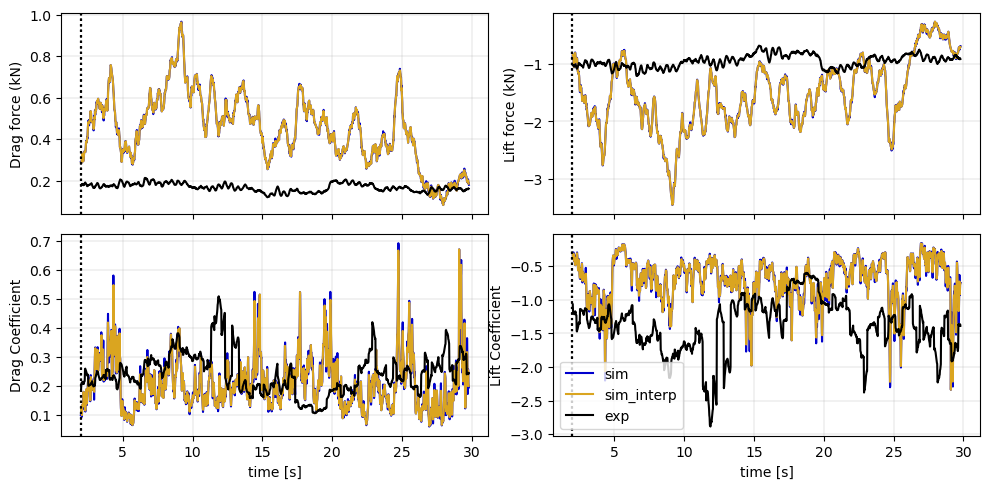

In [180]:
# first glance at drag and lift forces
plt.style.use('default')
time_threshold = 2.0 #12.0 # s

vars = ['Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
colors = {'exp': 'k', 'sim': 'mediumblue', 'sim_interp': 'goldenrod'}
keys = ['sim','sim_interp','exp']

fig, axs = plt.subplots(2,2,figsize=[10,5],sharex=True) #, dpi=300) #, sharey=True)
# plt.suptitle('u='+u+' m/s')
# for n,var in enumerate(vars):
for var,ax in zip(vars, axs.ravel()):
    for key in keys:
        pltdata = alldata[key][var][alldata[key][var].index > 2.0]
        ax.plot(pltdata, label=key, color=colors[key])
        ax.axvline(time_threshold, linestyle=':', color='k')
        ax.set_ylabel(var)
        # ax.legend()
        # axs[0].set_xlim([15, 20])
        # axs[0].set_ylim([0.0, 4.0])

for ax in axs.ravel():
    ax.grid(lw=0.25)
    # ax.legend()

for ax in axs[-1,:]:
    ax.set_xlabel('time [s]')

axs[-1,-1].legend()

plt.tight_layout()

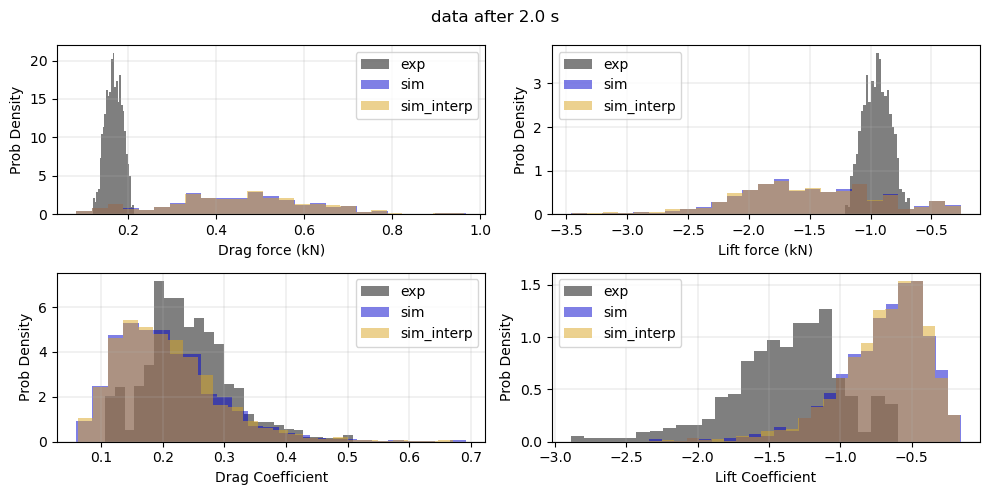

In [181]:
# histograms
plotdata = interp_sim_data[interp_sim_data.index > time_threshold]
plt_exp_data = exp_data[exp_data.index > time_threshold]

vars = ['Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
nbins = 25

# for k,angle in enumerate(float_list_to_str_list(tracker_angles0)):
fig, axs = plt.subplots(2,2,figsize=[10,5]) #, dpi=300) #, sharey=True)
plt.suptitle(f'data after {time_threshold} s')
# for j,u in enumerate(float_list_to_str_list(u_refs0)):

for var,ax in zip(vars, axs.ravel()):
    for key in alldata.keys():
        pltdata = alldata[key][var][alldata[key][var].index > time_threshold]
        ax.hist(pltdata, bins=nbins, density=True, alpha=0.5, label=key, color=colors[key])
        ax.set_xlabel(var)
        ax.legend()

for ax in axs.ravel():
    ax.grid(lw=0.25)
    ax.legend()
    ax.set_ylabel('Prob Density')

# # for ax in axs:
# axs[-1].set_xlabel('time [s]')

plt.tight_layout()

In [182]:
# compute errors
keys = ['sim_interp']
comps = ['u (m/s)','v (m/s)','w (m/s)','vel_mag (m/s)','Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
baseline = 'exp'

mean_abs_err = {}
mean_perc_err = {}
for key in keys:
    mean_abs_err[key] = {}
    mean_perc_err[key] = {}
    for comp in comps:
        mean_abs_err[key][comp] = round(float(np.nanmean(alldata[key][comp].values - alldata[baseline][comp].values)),4)
        mean_perc_err[key][comp] = 100*round(float(np.nanmean((alldata[key][comp].values - alldata[baseline][comp].values)/alldata[baseline][comp].values)),3)
mean_abs_err

{'sim_interp': {'u (m/s)': 4.3814,
  'v (m/s)': -2.1825,
  'w (m/s)': 0.1035,
  'vel_mag (m/s)': 4.0069,
  'Drag force (kN)': 0.2726,
  'Lift force (kN)': -0.5266,
  'Drag Coefficient': -0.0373,
  'Lift Coefficient': 0.68}}

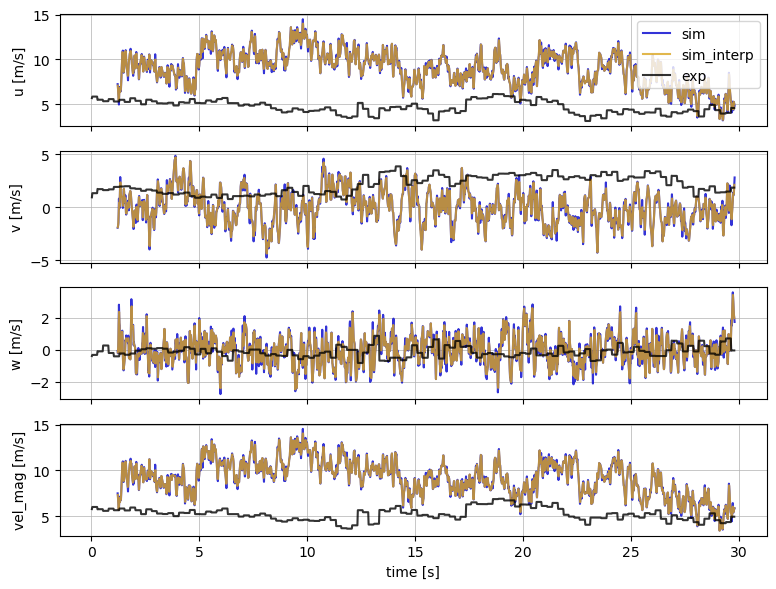

In [183]:
# plot velocity signals
fig, axs = plt.subplots(4,1, figsize=[8,6], sharex=True)

comps = ['u','v','w','vel_mag']
vars = ['sim','sim_interp','exp']
# vars = ['exp']

for comp,ax in zip(comps, axs.ravel()):
    for var in vars:
        ax.plot(alldata[var][comp+' (m/s)'], label=var, alpha=0.8, color=colors[var])
        ax.set_ylabel(f"{comp} [m/s]")
    ax.grid(lw=0.5)
axs[0].legend()
axs[-1].set_xlabel("time [s]")
plt.tight_layout()

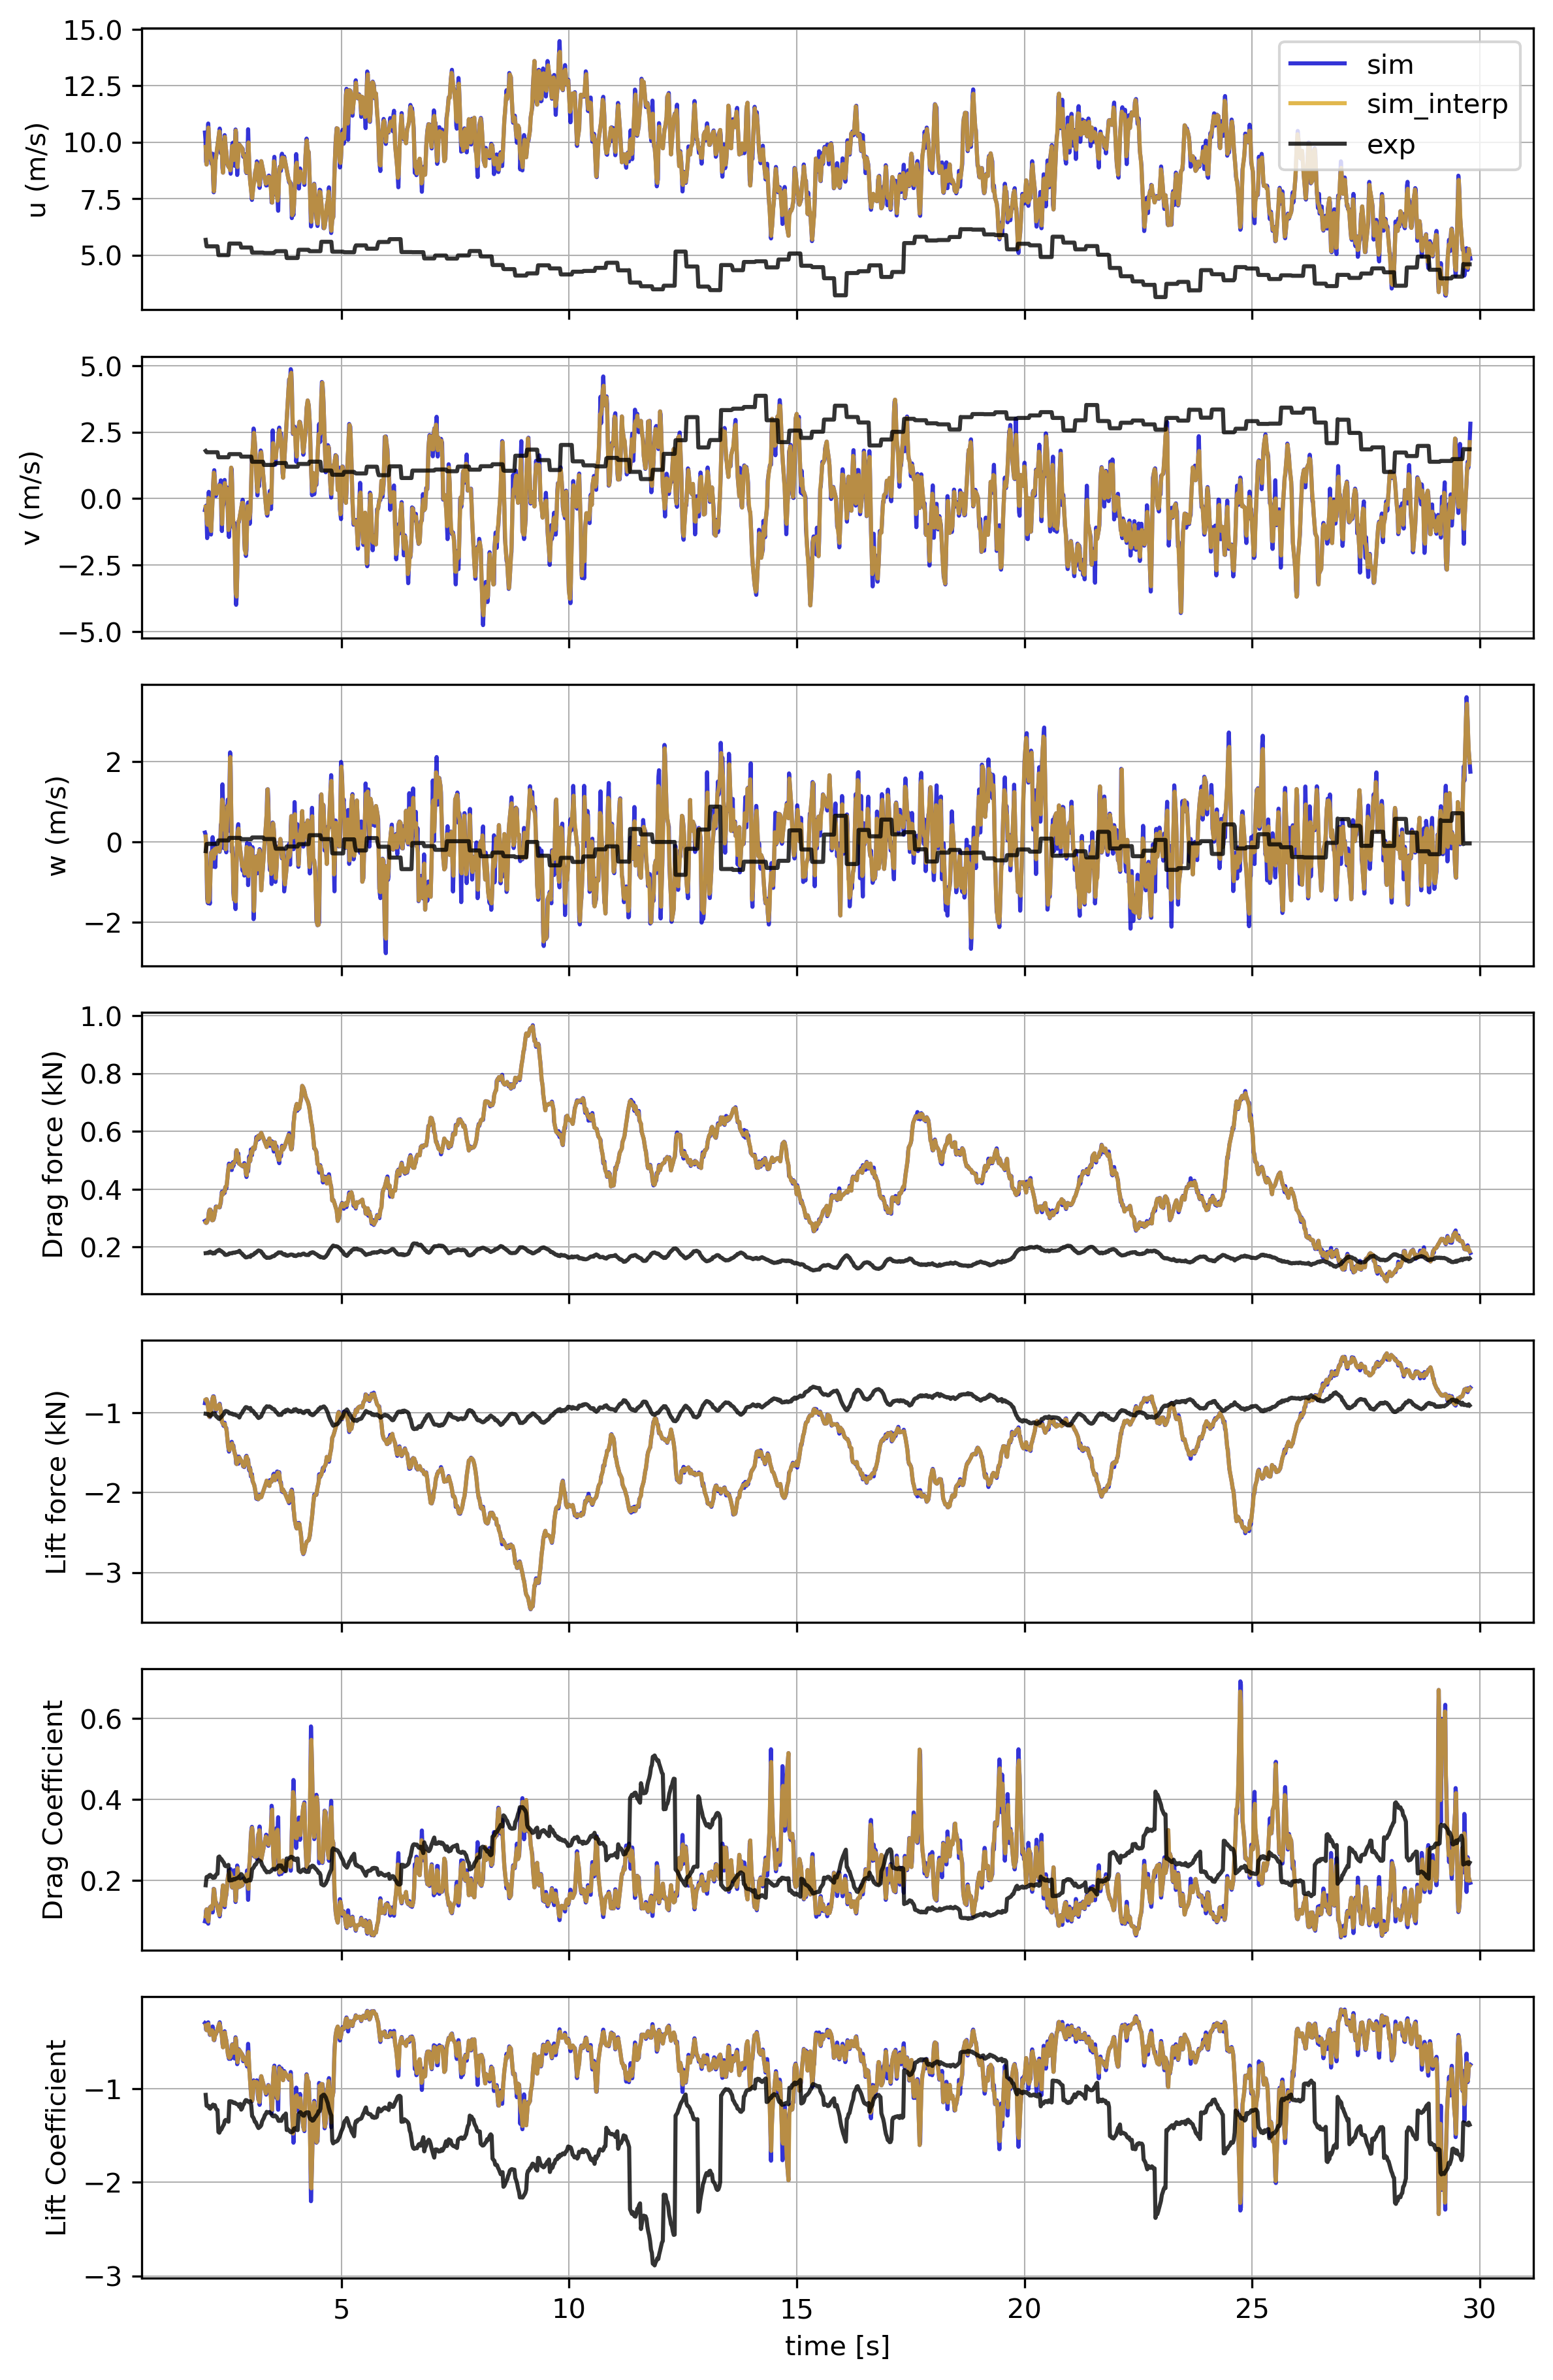

In [184]:
# plot velocity signals and drag and lift force
comps = ['u (m/s)','v (m/s)','w (m/s)','Drag force (kN)', 'Lift force (kN)','Drag Coefficient', 'Lift Coefficient']
vars = ['sim','sim_interp','exp']
# vars = ['exp']

fig, axs = plt.subplots(len(comps),1, figsize=[8,len(comps)*1.75], sharex=True, dpi=300)

for comp,ax in zip(comps, axs.ravel()):
    for var in vars:
        pltdata = alldata[var][comp][alldata[var][comp].index > 2.0]
        ax.plot(pltdata, label=var, alpha=0.8, color=colors[var])
        ax.set_ylabel(f"{comp}")
    ax.grid(lw=0.5)
axs[0].legend()
axs[-1].set_xlabel("time [s]")
plt.tight_layout()

In [185]:
# compute flow metrics
def compute_TI(u,v,w):
    umag = (u**2 + v**2 + w**2)**0.5
    
    Iu = np.std(u, axis=0) / np.mean(umag, axis=0)
    Iv = np.std(v, axis=0) / np.mean(umag, axis=0)
    Iw = np.std(w, axis=0) / np.mean(umag, axis=0)

    return Iu, Iv, Iw

TI = {}
for key in alldata.keys():
    TI[key] = {}
    TI[key]['Iu'], TI[key]['Iv'], TI[key]['Iw'] = compute_TI(alldata[key]['u (m/s)'], alldata[key]['v (m/s)'], alldata[key]['w (m/s)'])
    print(f'{key}: Iu, Iv, Iw = {TI[key]['Iu']:.3f}, {TI[key]['Iv']:.3f}, {TI[key]['Iw']:.3f}')

exp: Iu, Iv, Iw = 0.135, 0.160, 0.062
sim: Iu, Iv, Iw = 0.210, 0.170, 0.101
sim_interp: Iu, Iv, Iw = 0.208, 0.167, 0.095


In [186]:
# Smooth high frequency region
def runningMeanFast(x, N):
    """
    Calculates the running mean of an array x over a window size N.

    Returns:
        np.ndarray: Smoothed signal
    """
    return np.convolve(x, np.ones(N)/N, mode='same') 

def compute_spectra(u, U_mean, height, fs, overlap):
    """
    Computes the normalized energy spectrum of a velocity time series `u`,
    smooths the high-frequency tail, and returns the normalized frequency
    and smoothed normalized power spectral density.

    Parameters:
        u (array-like): Time series of velocity fluctuations (1D)
        U_mean (float): Mean flow velocity (for normalization)
        height (float): Reference height (for normalization)
        fs (float): Sampling frequency [Hz]
        overlap (int): Number of samples to overlap in Welch’s method

    Returns:
        nf_U_corr (np.ndarray): Normalized frequency array
        nPxxf_mod_U_corr (list of np.ndarray): Concatenated original and smoothed
            normalized power spectral density
    """

    # Length of the input time series (used for FFT size and window)
    nblock = len(u)

    # Use a Hamming window for spectral estimation
    win = np.hamming(math.floor(nblock/10))

    # Convert u to a pandas Series for easier handling (e.g., dropna, stats)
    U_corr = pd.Series(u)
    # do I need to detrend this? - probably not bc of "detrend = constant" in welch function call

    # Standard deviation of the fluctuations (used to normalize PSD)
    u_std = U_corr.std()

    # Compute power spectral density using Welch's method
    f_U_corr, Pxxf_U_corr = welch(U_corr.dropna(), fs, window=win, noverlap=overlap, nfft=nblock, detrend='constant', return_onesided=True) # detrend constant removes mean (zero-mean segments)
    
    # Normalize frequency: non-dimensional frequency = f * z / U_mean
    nf_U_corr = f_U_corr*height/abs(U_mean)

    # Normalize power: dimensionless spectral density
    nPxxf_U_corr = (f_U_corr*Pxxf_U_corr)/u_std**2

    # Identify index where normalized frequency > 0.3 (start smoothing here)
    index_highfreq_U_corr = list(np.where([abs(nf_U_corr)>0.3]))

    # Extract the high-frequency tail to smooth
    nPxxf_smooth_U_corr = nPxxf_U_corr[index_highfreq_U_corr[0][0]:len(nPxxf_U_corr)]

    # Apply running mean to smooth the high-frequency region
    avg_window_size = int(nblock/6)
    nPxxf_smooth_U_corr = runningMeanFast(nPxxf_smooth_U_corr,avg_window_size) # 200)

    # Concatenate the low-frequency part (unsmoothed) with the smoothed tail
    # nPxxf_mod_U_corr = [nPxxf_U_corr[0:index_highfreq_U_corr[0][0]-1],nPxxf_smooth_U_corr]
    nPxxf_mod_U_corr = nPxxf_U_corr # without smoothing

    # return nf_U_corr, nPxxf_mod_U_corr
    return nf_U_corr, nPxxf_mod_U_corr

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_218928/4077353783.py:30: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")


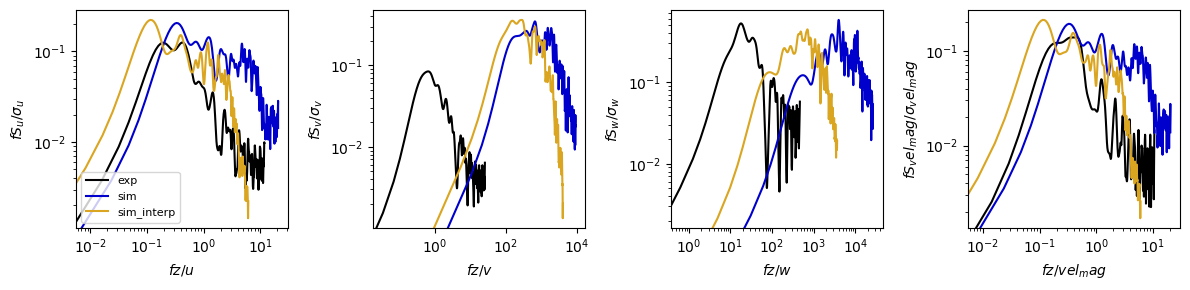

In [187]:
# spectra of flow
fs = {'exp': 50, 'sim': 1/dt_sim, 'sim_interp': 50} # Hz
overlap = 0

vars = alldata.keys()
comps = ['u','v','w','vel_mag']

nf_corr = {}; nPxxf_mod_corr = {}
U_mean = {}

for var in vars:
    U_mean[var] = {}
    for comp in comps:
        # Compute the mean while ignoring NaN values
        U_mean[var][comp] = float(np.nanmean(alldata[var][comp+' (m/s)'].values))

for var in vars:
    nf_corr[var] = {}
    nPxxf_mod_corr[var] = {}
    for comp in comps:
        nf_corr[var][comp], nPxxf_mod_corr[var][comp] = compute_spectra(alldata[var][comp+' (m/s)'].values.squeeze(), U_mean[var][comp], zloc, fs[var], overlap)
        
fig, axs = plt.subplots(1,4, figsize=[12,3]) #, sharey=True)

for var in vars:
    for comp,ax in zip(comps, axs.ravel()):
        # ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp][1])]), nPxxf_mod_corr[var][comp][1], color=colors[var], label=var)       
        ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp])]), nPxxf_mod_corr[var][comp], color=colors[var], label=var)            
        ax.set_xlabel(f"$fz/{comp}$")
        ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")
axs[0].legend(loc='lower left',fontsize=8)
# axs[0].set_title('streamwise u spectra')
# axs[0].set_xlim(10e-3, 10e-1)
# axs[0].set_ylim(10e-3, 10e-1)
plt.tight_layout()

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_218928/3043309257.py:30: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")


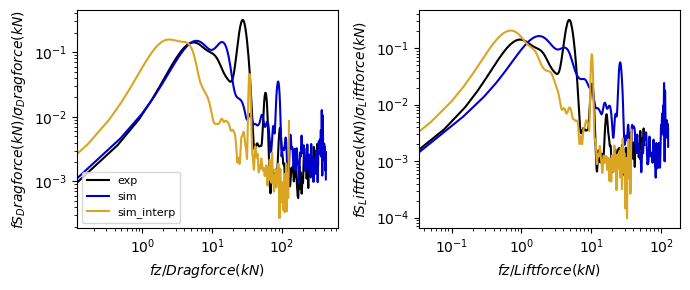

In [188]:
# spectra of loads
fs = {'exp': 50, 'sim': 1/dt_sim, 'sim_interp': 50} # Hz
overlap = 0

vars = alldata.keys()
comps = ['Drag force (kN)', 'Lift force (kN)']

nf_corr = {}; nPxxf_mod_corr = {}
comp_mean = {}

for var in vars:
    comp_mean[var] = {}
    for comp in comps:
        # Compute the mean while ignoring NaN values
        comp_mean[var][comp] = float(np.nanmean(alldata[var][comp].values))

for var in vars:
    nf_corr[var] = {}
    nPxxf_mod_corr[var] = {}
    for comp in comps:
        nf_corr[var][comp], nPxxf_mod_corr[var][comp] = compute_spectra(alldata[var][comp].values.squeeze(), comp_mean[var][comp], zloc, fs[var], overlap)
        
fig, axs = plt.subplots(1,2, figsize=[7,3]) #, sharey=True)

for var in vars:
    for comp,ax in zip(comps, axs.ravel()):
        # ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp][1])]), nPxxf_mod_corr[var][comp][1], color=colors[var], label=var)       
        ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp])]), nPxxf_mod_corr[var][comp], color=colors[var], label=var)            
        ax.set_xlabel(f"$fz/{comp}$")
        ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")
axs[0].legend(loc='lower left',fontsize=8)
# axs[0].set_title('streamwise u spectra')
# axs[0].set_xlim(10e-3, 10e-1)
# axs[0].set_ylim(10e-3, 10e-1)
plt.tight_layout()